# A Boolean Circuit as a PyTorch Geometric Graph

A combinational logic circuit is literally a directed acyclic graph:
gates are nodes, wires are edges, and a gate's value depends only on its
predecessors', computed in topological order. Graph neural network
MESSAGE PASSING -- each node aggregates its in-neighbors' values, applies
a function, repeat -- is structurally the SAME operation as circuit
EVALUATION. This notebook makes that correspondence literal: the full
adder already implemented in `dgs.computer_engineering.full_adder` is
represented as a `torch_geometric.data.Data` graph and evaluated two very
different ways --

1. **Exact simulation**: a custom `MessagePassing` layer that IS the
   circuit, structurally -- no training, no learned weights, just enough
   rounds of message passing for every node to reach its true value.
2. **A small trained GCN**: the typical PyTorch-Geometric ML workflow --
   learn the same function from 8 labeled examples via gradient descent.

Both are checked against the SAME ground truth
(`dgs.computer_engineering.full_adder`) on ALL 8 rows of the truth table.
Engine: `dgs/circuit_graph_gnn.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt

from dgs.computer_engineering import full_adder
from dgs import circuit_graph_gnn as cgg

print('Setup complete. torch_geometric version check:')
import torch_geometric
print(torch_geometric.__version__)


Setup complete. torch_geometric version check:
2.8.0.post1


C:\Users\mrjel\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 1. The Full Adder as a Graph

8 nodes (3 inputs, 5 gates), 10 directed edges (wires). Node features are
a one-hot gate type plus the input value (meaningful only for the 3 INPUT
nodes).


In [2]:
data = cgg.build_full_adder_graph(A=1, B=0, Cin=1)
print(data)
print('\nnode features (gate-type one-hot + input value):')
for name, row in zip(cgg.NODE_NAMES, data.x.tolist()):
    print(f'  {name:>10}: {row}')


Data(x=[8, 5], edge_index=[2, 10], num_nodes=8)

node features (gate-type one-hot + input value):
           A: [1.0, 0.0, 0.0, 0.0, 1.0]
           B: [1.0, 0.0, 0.0, 0.0, 0.0]
         Cin: [1.0, 0.0, 0.0, 0.0, 1.0]
        XOR1: [0.0, 1.0, 0.0, 0.0, 0.0]
      XOR2_S: [0.0, 1.0, 0.0, 0.0, 0.0]
        AND1: [0.0, 0.0, 1.0, 0.0, 0.0]
        AND2: [0.0, 0.0, 1.0, 0.0, 0.0]
    OR1_Cout: [0.0, 0.0, 0.0, 1.0, 0.0]


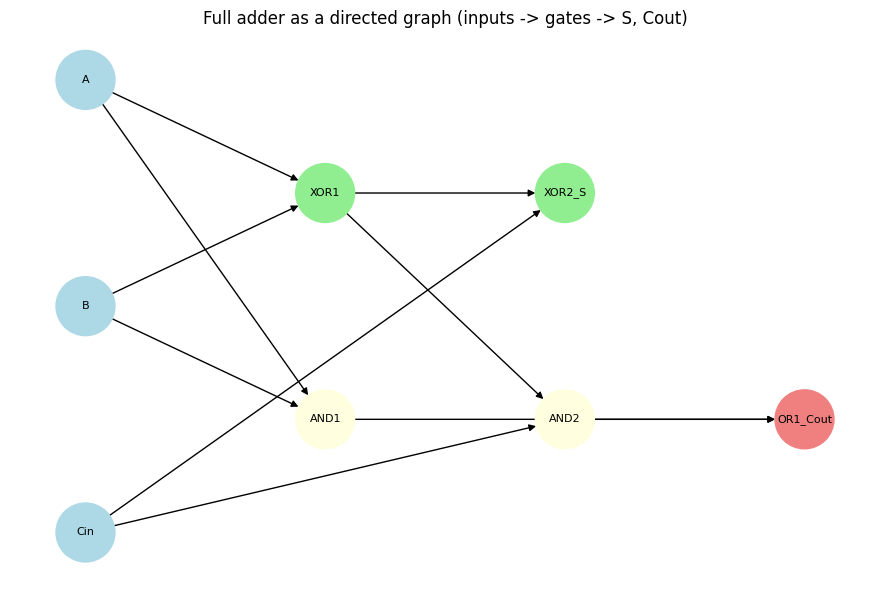

In [3]:
import networkx as nx

fig, ax = plt.subplots(figsize=(9, 6))
G = nx.DiGraph()
for i, name in enumerate(cgg.NODE_NAMES):
    G.add_node(i, label=name)
edges = cgg.EDGE_INDEX.t().tolist()
G.add_edges_from(edges)

pos = {0: (0, 2), 1: (0, 1), 2: (0, 0),      # inputs
       3: (1, 1.5), 5: (1, 0.5),              # XOR1, AND1
       4: (2, 1.5), 6: (2, 0.5),              # XOR2/S, AND2
       7: (3, 0.5)}                           # OR1/Cout

colors = ['lightblue' if cgg.NODE_GATE_TYPE[i] == 'INPUT' else
          'lightgreen' if cgg.NODE_GATE_TYPE[i] == 'XOR' else
          'lightyellow' if cgg.NODE_GATE_TYPE[i] == 'AND' else 'lightcoral'
          for i in range(cgg.N_NODES)]
nx.draw(G, pos, ax=ax, with_labels=False, node_color=colors, node_size=1800, arrows=True)
labels = {i: name for i, name in enumerate(cgg.NODE_NAMES)}
nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8)
ax.set_title('Full adder as a directed graph (inputs -> gates -> S, Cout)')
plt.tight_layout()
plt.savefig('circuit_graph_gnn_topology.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Exact Simulation via Message Passing

`CircuitMessagePassing` runs `DAG_DEPTH+1` rounds of message passing;
each round, every gate node aggregates its in-neighbors' CURRENT values
and applies its own boolean operation. Input nodes never change. After
enough rounds, every node has reached its true steady-state value -- the
same reason a physical circuit needs a few gate delays to settle.


In [4]:
for A in (0, 1):
    for B in (0, 1):
        for Cin in (0, 1):
            sim = cgg.simulate_full_adder_via_message_passing(A, B, Cin)
            truth = full_adder(A, B, Cin)
            match = 'OK' if (sim['S']==truth['S'] and sim['Cout']==truth['Cout']) else 'MISMATCH'
            print(f"A={A} B={B} Cin={Cin}: sim S={sim['S']} Cout={sim['Cout']}, "
                  f"truth S={truth['S']} Cout={truth['Cout']}  [{match}]")


A=0 B=0 Cin=0: sim S=0 Cout=0, truth S=0 Cout=0  [OK]
A=0 B=0 Cin=1: sim S=1 Cout=0, truth S=1 Cout=0  [OK]
A=0 B=1 Cin=0: sim S=1 Cout=0, truth S=1 Cout=0  [OK]
A=0 B=1 Cin=1: sim S=0 Cout=1, truth S=0 Cout=1  [OK]
A=1 B=0 Cin=0: sim S=1 Cout=0, truth S=1 Cout=0  [OK]
A=1 B=0 Cin=1: sim S=0 Cout=1, truth S=0 Cout=1  [OK]
A=1 B=1 Cin=0: sim S=0 Cout=1, truth S=0 Cout=1  [OK]
A=1 B=1 Cin=1: sim S=1 Cout=1, truth S=1 Cout=1  [OK]


In [5]:
check = cgg.verify_all_truth_table_rows()
print(f"all 8 rows match: {check['all_match']}  ({check['n_mismatches']} mismatches)")


all 8 rows match: True  (0 mismatches)


## 3. A Small Trained GCN, for Contrast

`TinyCircuitGCN` (2 `GCNConv` layers + global mean pool) learns the same
function from the 8 labeled rows via gradient descent -- with only 8
examples, this is closer to memorization than generalization, stated
plainly rather than oversold.


In [6]:
result = cgg.train_tiny_gcn(n_epochs=500, seed=0)
print(f"final training loss: {result['final_loss']:.4f}")
print(f"correct on {result['n_correct_of_8']}/8 rows after training\n")
for p in result['predictions']:
    mark = 'OK' if p['S_correct'] and p['Cout_correct'] else 'WRONG'
    print(f"A={p['A']} B={p['B']} Cin={p['Cin']}: pred S={p['pred_S']:.2f}(true {p['true_S']}) "
          f"Cout={p['pred_Cout']:.2f}(true {p['true_Cout']})  [{mark}]")


final training loss: 0.0105
correct on 8/8 rows after training

A=0 B=0 Cin=0: pred S=0.02(true 0) Cout=0.00(true 0)  [OK]
A=0 B=0 Cin=1: pred S=0.98(true 1) Cout=0.00(true 0)  [OK]
A=0 B=1 Cin=0: pred S=0.98(true 1) Cout=0.00(true 0)  [OK]
A=0 B=1 Cin=1: pred S=0.02(true 0) Cout=1.00(true 1)  [OK]
A=1 B=0 Cin=0: pred S=0.98(true 1) Cout=0.00(true 0)  [OK]
A=1 B=0 Cin=1: pred S=0.02(true 0) Cout=1.00(true 1)  [OK]
A=1 B=1 Cin=0: pred S=0.02(true 0) Cout=1.00(true 1)  [OK]
A=1 B=1 Cin=1: pred S=0.98(true 1) Cout=1.00(true 1)  [OK]


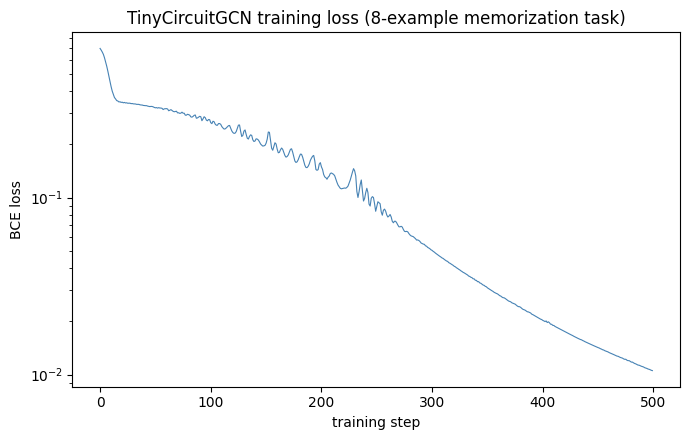

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(result['loss_history'], color='steelblue', lw=0.8)
ax.set_xlabel('training step'); ax.set_ylabel('BCE loss')
ax.set_yscale('log')
ax.set_title('TinyCircuitGCN training loss (8-example memorization task)')
plt.tight_layout()
plt.savefig('circuit_graph_gnn_training_loss.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Engineering Interpretation

- Section 2's "exact" simulator and Section 3's "trained" GCN are
  structurally the same OBJECT (a graph neural network operating on the
  same 8-node graph) doing two philosophically different things: one
  computes the circuit's function BY CONSTRUCTION (the message-passing
  update rule literally implements XOR/AND/OR), the other APPROXIMATES it
  by fitting parameters to examples. Getting both to 8/8 correct is not
  the same achievement -- one is guaranteed, the other is a (successful,
  here) optimization result.
- `verify_all_truth_table_rows` checking ALL 8 rows (not a sample) matters
  specifically because a boolean function's "coverage" is finite and
  enumerable -- unlike a continuous-domain physics check, there's no
  excuse for spot-checking here when exhaustive verification costs
  nothing.
- The DAG-depth-plus-one round count in `CircuitMessagePassing` is a real
  design constraint, not an arbitrary choice: fewer rounds and OR1/Cout
  (3 hops from the inputs) wouldn't have received all its predecessors'
  values yet.


## 5. Research Discussion

- `dgs.boolean_algebra`/`dgs.logic_timing` (if they model larger circuits,
  e.g. a ripple-carry adder chain) would be natural graphs to extend this
  same message-passing simulator to -- the round count would need to scale
  with the chain's depth, a concrete test of whether
  `CircuitMessagePassing`'s "DAG depth + 1" rule generalizes.
- `TinyCircuitGCN`'s 8-example memorization (Section 3) raises the more
  interesting question this notebook doesn't answer: could a GCN trained
  on SMALLER circuits (e.g. individual XOR/AND/OR gates) generalize to
  PREDICT a novel larger circuit's truth table zero-shot, the way a
  message-passing simulator built from the same primitive gate rules
  trivially does? That's a genuine open comparison between learned and
  structural circuit models.
- `dgs.spacetime_circuit_timing` (if it models real gate delays, not just
  boolean logic) is a natural pairing: `CircuitMessagePassing`'s "rounds"
  are a discrete proxy for continuous propagation delay; comparing the two
  models' predictions for WHEN a signal settles (not just its final value)
  would be a genuine physics/CS crossover.


## 6. Possible Experiments

1. Build a second circuit graph (e.g. a half adder, or a 2-bit ripple
   adder chaining two full adders) and confirm `CircuitMessagePassing`'s
   general update rule (not full-adder-specific) still exactly simulates
   it, with round count scaled to the new DAG's depth.
2. Shrink `TinyCircuitGCN`'s hidden width and see how few parameters it
   needs to still reach 8/8 on this tiny dataset -- a rough lower bound on
   the "capacity" needed to represent a full adder's function.
3. Add a 9th, held-out-style test: perturb one node's gate-type feature
   (e.g. mislabel AND1 as OR) and confirm BOTH the exact simulator (which
   should now compute a WRONG but well-defined different function) and the
   trained GCN (which was never shown this perturbed case) respond
   differently -- a concrete illustration of "correct by construction"
   vs. "correct by fitting."


## 7. Future Improvements

- `CircuitMessagePassing`'s `aggregate` method uses a Python for-loop over
  edges (fine for an 8-node/10-edge graph, would not scale to a large
  circuit) -- a vectorized `torch_scatter`-based aggregation would be
  needed for anything bigger.
- `train_tiny_gcn` always trains from a fixed random seed by default in
  the demo; a proper ablation (several seeds, reporting mean/variance of
  `n_correct_of_8`) would show whether 8/8 is reliable or a lucky
  initialization on this tiny dataset.
